In [1]:
import greenlearning as gl
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

Using TensorFlow 2 backend.

Instructions for updating:
non-resource variables are not supported in the long term


(100, 100)


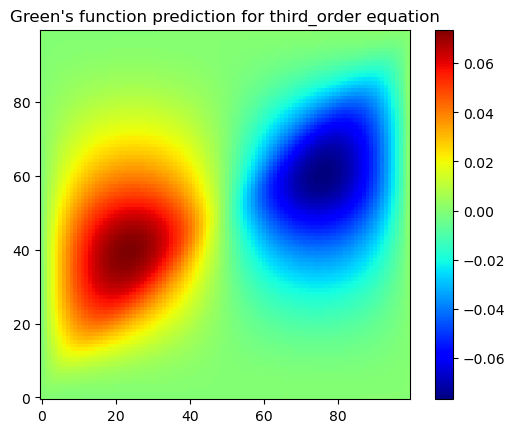

In [22]:
eq = 'third_order'
resample = 1
G_pred = np.loadtxt(f'results_csv/Green_{eq}_rational_0_Ntrain75_noiseratio0.010000_resample{resample}_repeat0.csv', delimiter=',') # [s, x]
# G_pred = pd.read_csv(f'results_csv/Green_{eq}_rational_0_Ntrain75_noiseratio0.010000_resample1_repeat0.csv')
print(G_pred.shape)

plt.figure()
plt.imshow(G_pred, origin='lower', cmap='jet')
plt.colorbar()
plt.title(f'Green\'s function prediction for {eq} equation')
plt.show()

/tmp/ipykernel_235487/1989059879.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_est = np.trapz(integrand, x=domain_u, axis=0) # (100, N_test)  # integrate over y (axis=1)


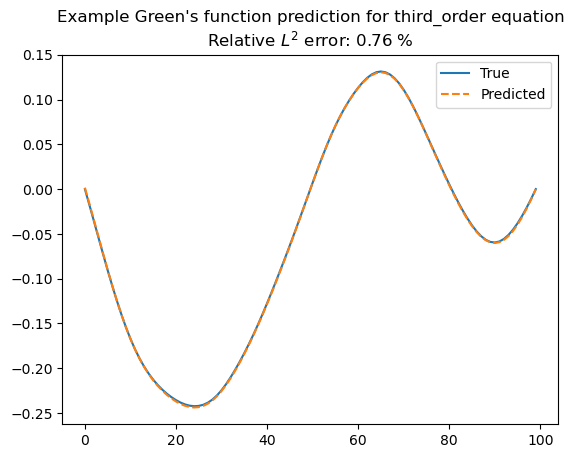

In [23]:
def relative_L2_error(y_true, y_pred, eps=1e-12):
    """
    Uniform-grid discrete relative L2 error, expressed as a %, averaged over examples on axis=0.
    y_true, y_pred shape: (B, ...grid axes...)
    """
    # reduce over all non-batch axes → per-example norms
    reduce_axes = tuple(range(1, y_true.ndim))
    num = np.sqrt(np.sum((y_pred - y_true)**2, axis=reduce_axes))
    den = np.sqrt(np.sum(y_true**2,          axis=reduce_axes))
    rel = num / (den + eps)          # shape (B,)
    return 100 * np.mean(rel)             # scalar

# calculate metrics
data_path = f'examples/datasets/{eq}.mat'
raw_data = sp.io.loadmat(data_path)

N_test = 20

u = raw_data['F'][::2 * resample, -N_test:] # (100, N_test)
v = raw_data['U'][::resample, -N_test:] # (100, N_test)

domain_u = raw_data['X'][::resample, 0] # (100,)

integrand = G_pred[:, :, None] * u[:, None, :]  # (100, 100, N_test)  # broadcast u over columns (y-axis)
v_est = np.trapz(integrand, x=domain_u, axis=0) # (100, N_test)  # integrate over y (axis=1)

vT = v.T
v_estT = v_est.T

error = relative_L2_error(vT, v_estT)

plt.figure()
plt.plot(vT[0], label='True')
plt.plot(v_estT[0], label='Predicted', linestyle='dashed')
plt.title(f'Example Green\'s function prediction for {eq} equation\nRelative $L^2$ error: {error:.2f} %')
plt.legend()
plt.show()